<a href="https://colab.research.google.com/github/di-claro-batera/faculdade_data_science/blob/main/Algoritmo_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = [15,10]

In [17]:
url = 'https://raw.githubusercontent.com/higoramario/univesp-com410-aprendizado-de-maquinas/main/social-network-ads.csv'
compras = pd.read_csv(url, sep=',')
compras.head(10)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
5,27,58000,0
6,27,84000,0
7,32,150000,1
8,25,33000,0
9,35,65000,0


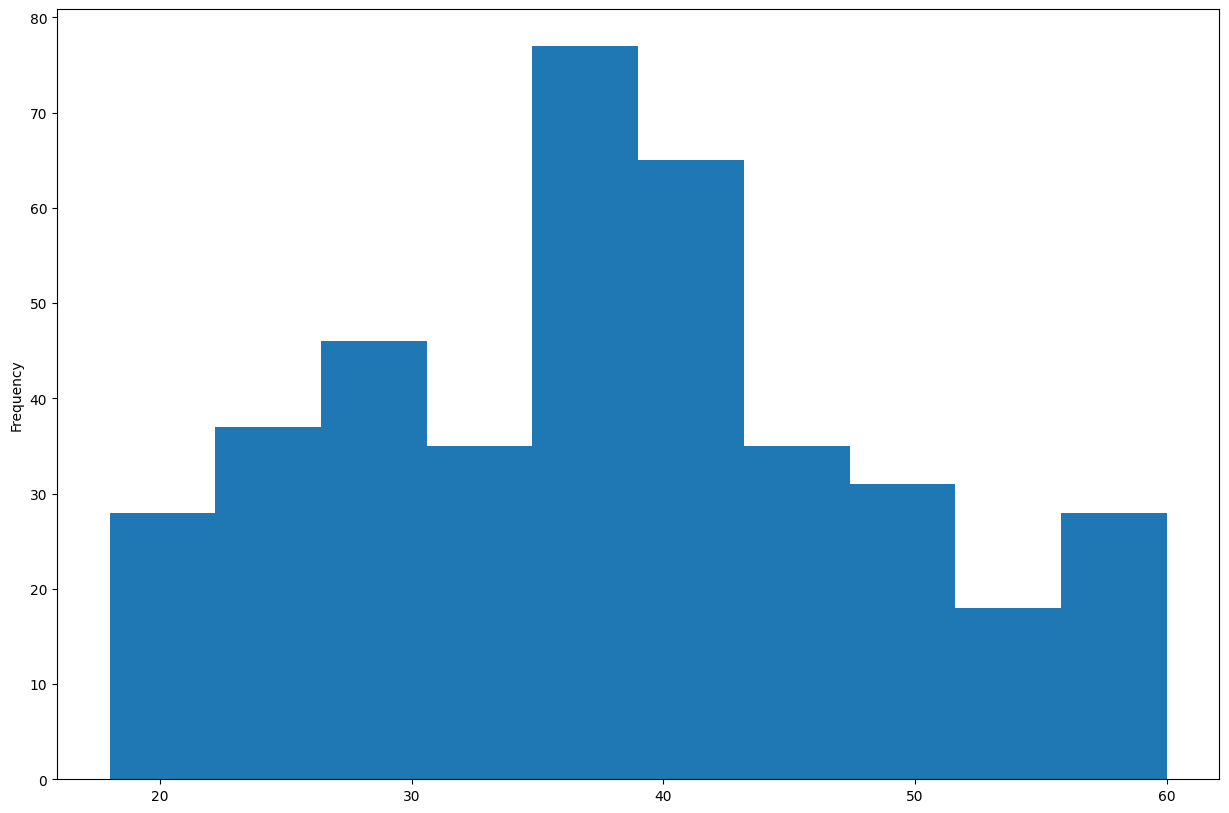

In [18]:
compras['Age'].plot.hist()
plt.show()

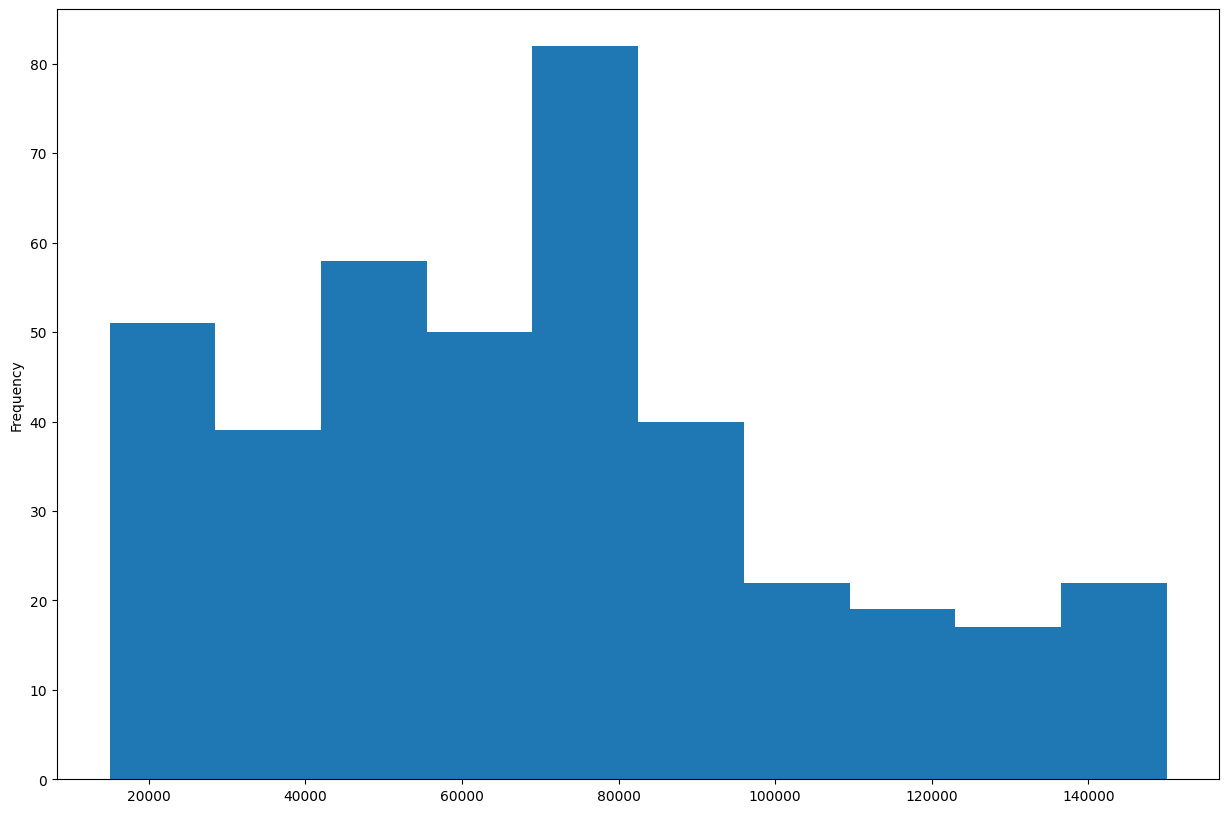

In [19]:
plt.figure(figsize=(15,10))
compras['EstimatedSalary'].plot.hist()
plt.show()

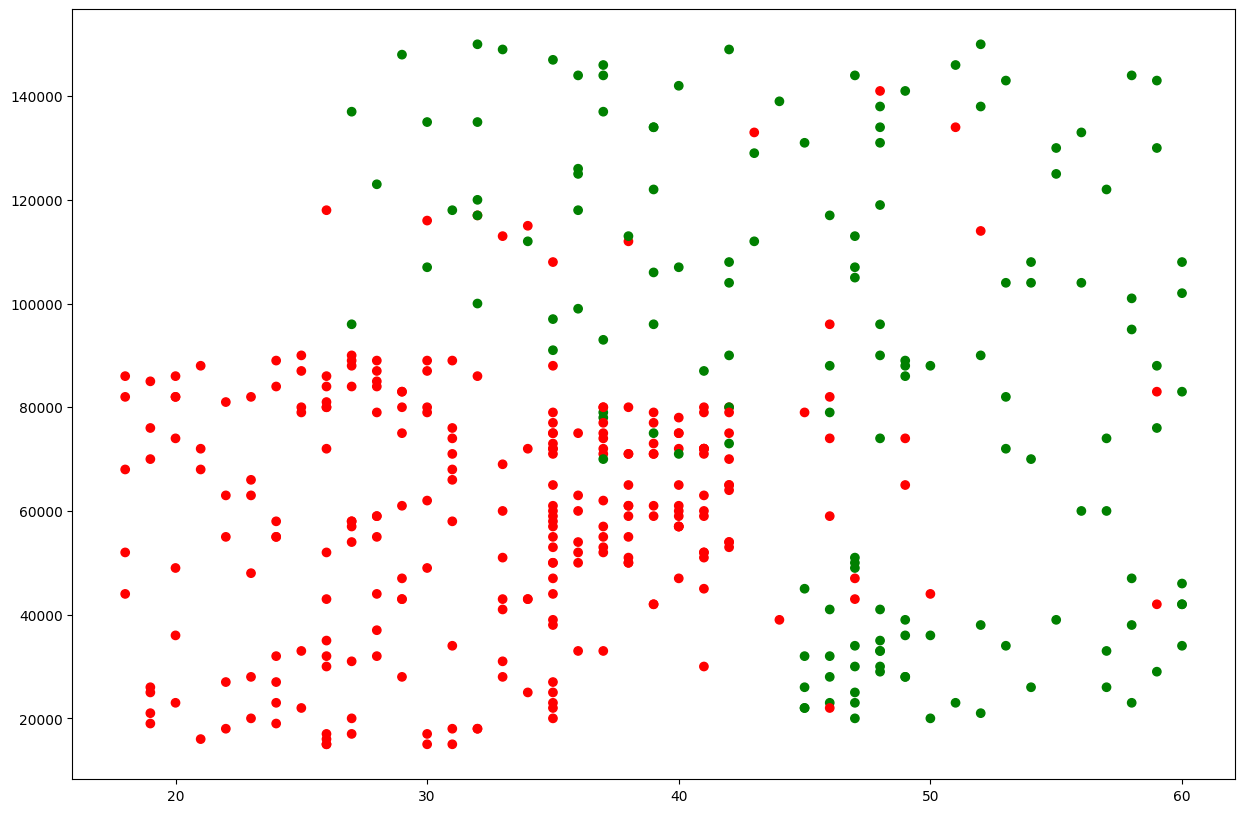

In [20]:
fig, ax = plt.subplots()
colors = {0:'red', 1:'green'}
ax.scatter(compras['Age'], compras['EstimatedSalary'], c=compras['Purchased'].map(colors))
plt.show()

In [21]:
atributos = compras[['Age','EstimatedSalary']]
classes = compras['Purchased']

In [22]:
compras_treino, compras_teste, classes_treino, classes_teste = train_test_split(atributos, classes, test_size=0.1)

In [23]:
scaler = StandardScaler()
scaler.fit(compras_treino)
compras_treino = scaler.fit_transform(compras_treino)
compras_teste = scaler.transform(compras_teste)

In [24]:
#funcao que recebe os atributos e classes do conjunto de testes, o classificador SVM e plota os resultados

def visualizarSVM(atributos_t, classes_t, classificador):
    atributos, classes = atributos_t, classes_t

    ano, salario = np.meshgrid(np.arange(start=atributos[:,0].min()-1, stop=atributos[:,0].max()+1, step=0.01),
                               np.arange(start=atributos[:,1].min()-1, stop=atributos[:,1].max()+1, step=0.01))

    plt.contourf(ano, salario, classificador.predict(np.array([ano.ravel(), salario.ravel()]).T).reshape(ano.shape),
                 alpha=0.75, cmap= ListedColormap(('red', 'green')))

    plt.xlim(ano.min(), ano.max())
    plt.ylim(salario.min(), salario.max())

    for i, j in enumerate(np.unique(classes)):
        plt.scatter(atributos[classes==j, 0], atributos[classes==j, 1],
                    c=ListedColormap(('red', 'green'))(i), label=j)

    plt.title('Classicação SVM')
    plt.xlabel('Ano')
    plt.ylabel('Salário Estimado')
    plt.legend()
    plt.show()

In [25]:
SVM_polinomial = SVC(kernel='poly', degree=3, gamma = 'scale', C = 1.0, coef0=2)
SVM_polinomial.fit(compras_treino, classes_treino)

SVC(coef0=2, kernel='poly')

In [26]:
predicao = SVM_polinomial.predict(compras_teste)
acuracia = accuracy_score(classes_teste, predicao)
print('Acurácia de classificação: {}'.format(round(acuracia,3)*100)+'%')

Acurácia de classificação: 87.5%


<ipython-input-24-ebadb32cd0f9>:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(atributos[classes==j, 0], atributos[classes==j, 1],


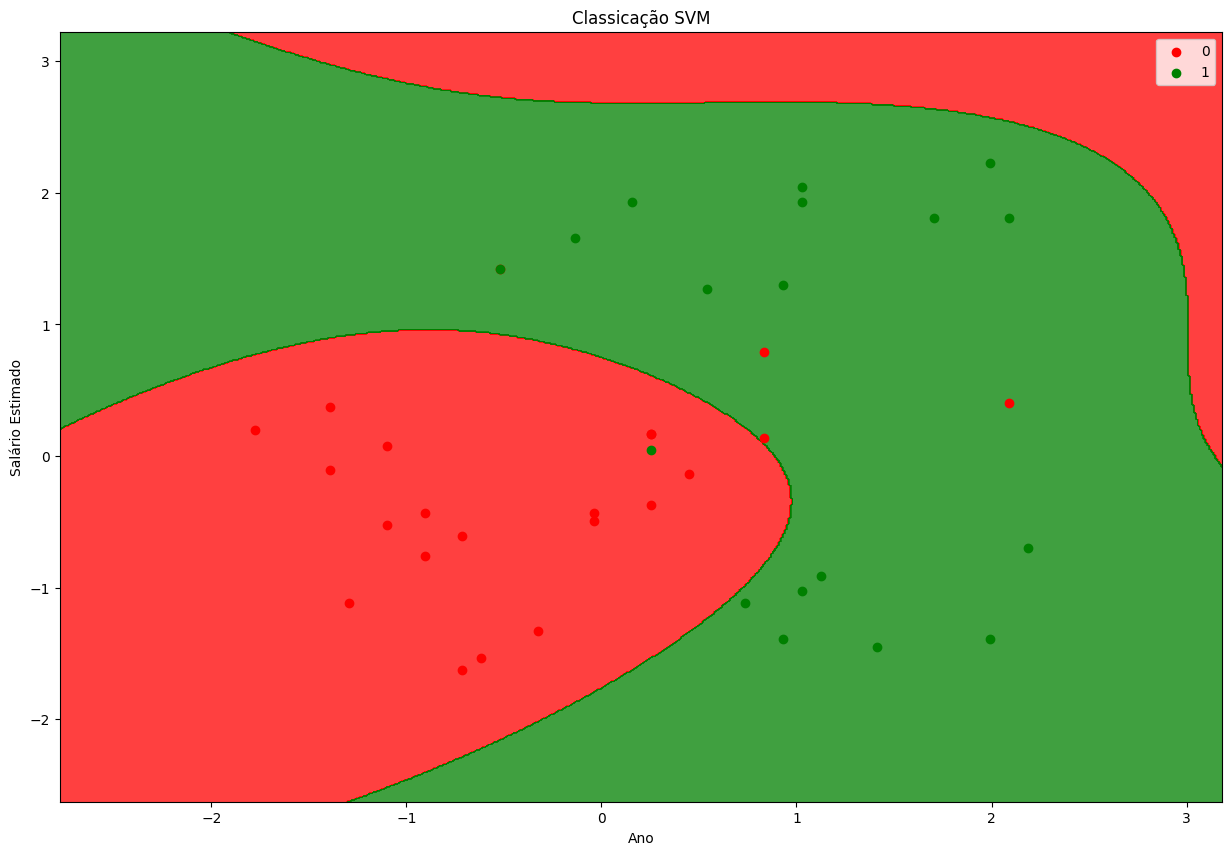

In [27]:
visualizarSVM(compras_teste, classes_teste, SVM_polinomial)

In [28]:
SVM_sigmoidal = SVC(kernel='sigmoid', gamma = 'scale', C = 0.2, coef0=2)
SVM_sigmoidal.fit(compras_treino, classes_treino)

SVC(C=0.2, coef0=2, kernel='sigmoid')

In [29]:
predicao_sigmoidal = SVM_sigmoidal.predict(compras_teste)
acuracia_sigmoidal = accuracy_score(classes_teste, predicao_sigmoidal)
print('Acurácia de classificação: {}'.format(round(acuracia_sigmoidal,3)*100)+'%')

Acurácia de classificação: 60.0%


<ipython-input-24-ebadb32cd0f9>:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(atributos[classes==j, 0], atributos[classes==j, 1],


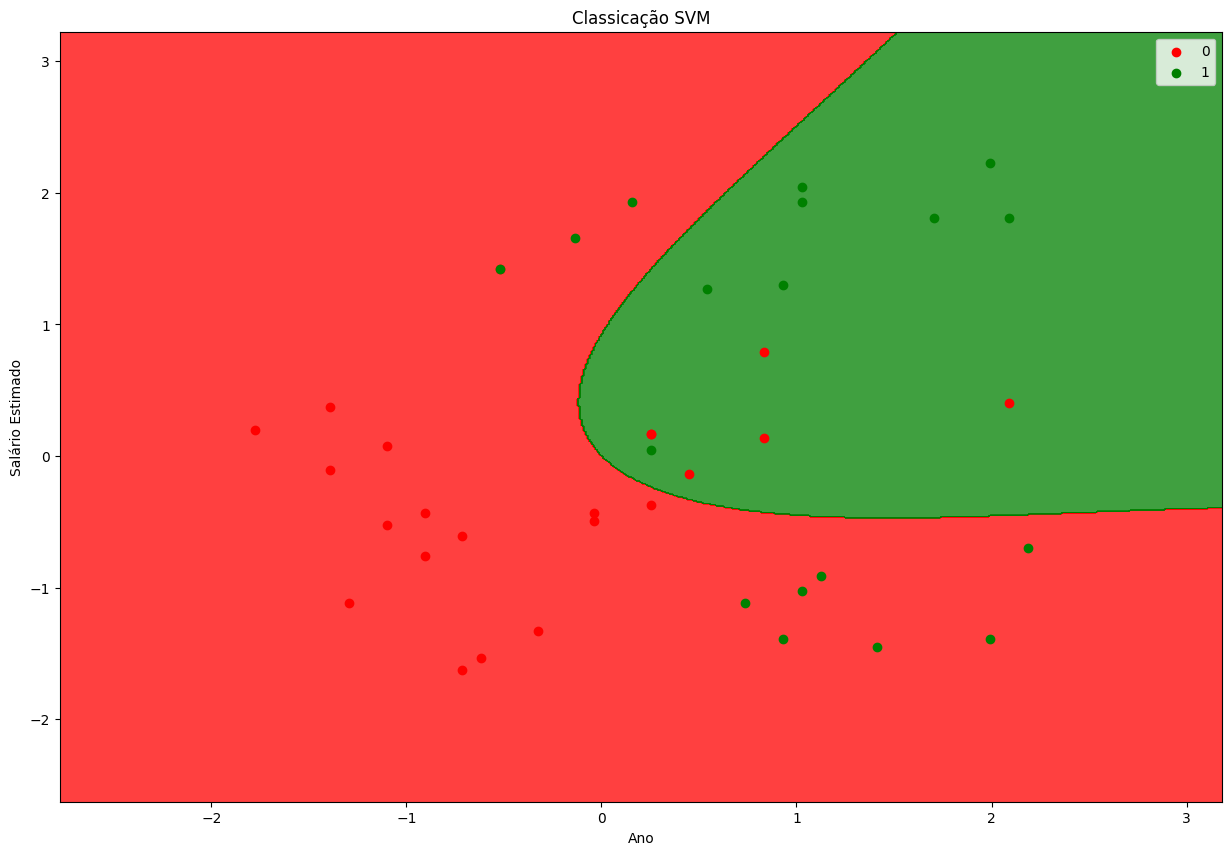

In [30]:
visualizarSVM(compras_teste, classes_teste, SVM_sigmoidal)